#  코드 설명
- 성능 올리는 피쳐만 자동으로 selection 버전
- ++ 공행성쌍 판단에 가중치를 두어 공행성을 놓치지 않게 함
- +++ 피쳐 추가함
- ++++기존 베이스라인에서 모델 튜닝 추가
- +++++ OverSampling
- ++++++ 공행성쌍 판단 로직 추가(3필터)
- +++++++ 기존 공행성 판단 코드에서 임계값만 0.325->0.35
- dropout 0.04으로 설정
$$ <BEST> 0.405435416


## 1. Import

In [17]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from catboost import CatBoostRegressor
from tqdm import tqdm
from datetime import datetime
from xgboost import XGBRegressor
import random
import os

## 2. 데이터 전처리

In [18]:
# Seed 고정
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# 📁 데이터 경로 한 곳에서 관리
PATH = "/Users/jab/Desktop/DACON/data/train.csv"

train = pd.read_csv(PATH)

- type 컬럼에는 '1'만 있음(컬럼 삭제)
- 결측값 없음
- 컬럼 분포 확인하기
- item_id는 저마다 교유한 hs4를 지님
- 이상치도 파악해보기
- 중량과 수량 모두 0인 값은 635개
- 전월/전년 대비 성장률 피쳐 생성
- 단가 피쳐 생성


================================================================================================

value를 공행성 파악 시에만 scaling, 학습 및 예측에선 X
- 유의미한 성능 변화 없음

In [19]:
# hs4 앞 두 자리 추출
train['hs2'] = train['hs4'].astype(str).str[:2]

# hs2 종류가 몇 개인지 출력
num_hs2 = train['hs2'].nunique()

print("hs4 앞 2자리(hs2) 개수:", num_hs2)

hs4 앞 2자리(hs2) 개수: 39


================================================================================================

In [20]:
# year, month, item_id 기준으로 value 합산 (seq만 다르다면 value 합산)
monthly = (
    train
    .groupby(["item_id", "year", "month"], as_index=False)["value"]
    .sum()
)

# year, month를 하나의 키(ym)로 묶기
monthly["ym"] = pd.to_datetime(
    monthly["year"].astype(str) + "-" + monthly["month"].astype(str).str.zfill(2)
)

# item_id × ym 피벗 (월별 총 무역량 매트릭스 생성)
pivot = (
    monthly
    .pivot(index="item_id", columns="ym", values="value")
    .fillna(0.0)
)

pivot

ym,2022-01-01,2022-02-01,2022-03-01,2022-04-01,2022-05-01,2022-06-01,2022-07-01,2022-08-01,2022-09-01,2022-10-01,...,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01,2025-04-01,2025-05-01,2025-06-01,2025-07-01
item_id,,,,,,,,,,,,,,,,,,,,,
AANGBULD,14276.0,52347.0,53549.0,0.0,26997.0,84489.0,0.0,0.0,0.0,0.0,...,428725.0,144248.0,26507.0,25691.0,25805.0,0.0,38441.0,0.0,441275.0,533478.0
AHMDUILJ,242705.0,120847.0,197317.0,126142.0,71730.0,149138.0,186617.0,169995.0,140547.0,89292.0,...,123085.0,143451.0,78649.0,125098.0,80404.0,157401.0,115509.0,127473.0,89479.0,101317.0
ANWUJOKX,0.0,0.0,0.0,63580.0,81670.0,26424.0,8470.0,0.0,0.0,80475.0,...,0.0,0.0,0.0,27980.0,0.0,0.0,0.0,0.0,0.0,0.0
APQGTRMF,383999.0,512813.0,217064.0,470398.0,539873.0,582317.0,759980.0,216019.0,537693.0,205326.0,...,683581.0,2147.0,0.0,25013.0,77.0,20741.0,2403.0,3543.0,32430.0,40608.0
ATLDMDBO,143097177.0,103568323.0,118403737.0,121873741.0,115024617.0,65716075.0,146216818.0,97552978.0,72341427.0,87454167.0,...,60276050.0,30160198.0,42613728.0,64451013.0,38667429.0,29354408.0,42450439.0,37136720.0,32181798.0,57090235.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
YSYHGLQK,0.0,543.0,766.0,1108.0,859.0,1426.0,2413.0,638.0,0.0,1199.0,...,188.0,541.0,696.0,8710.0,3175.0,2624.0,0.0,182.0,2128.0,10651.0
ZCELVYQU,373859.0,59900.0,31158.0,594407.0,648232.0,496737.0,210179.0,0.0,70748.0,15512.0,...,0.0,609803.0,23712.0,654630.0,4496.0,1177300.0,1187539.0,26434.0,115631.0,270262.0
ZGJXVMNI,1154724.0,1337622.0,1662893.0,1561647.0,1603223.0,1641942.0,1815161.0,1546959.0,1536799.0,1496906.0,...,3168505.0,3059865.0,1579976.0,1413293.0,3038078.0,2915914.0,3565526.0,3020051.0,2412781.0,2458481.0


## 3. 공행성쌍 탐색
- 각 (A, B) 쌍에 대해 lag = 1 ~ max_lag까지 Pearson 상관계수 계산
- 절댓값이 가장 큰 상관계수와 lag를 선택
- |corr| >= corr_threshold이면 A→B 공행성 있다고 판단

In [ ]:
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# ==========================================
# 0. DTW 및 정규화 함수 (NumPy 구현)
# ==========================================
def z_normalize(arr):
    """모양 비교를 위한 Z-Score 정규화 (표준편차 0 방지)"""
    std = np.std(arr)
    if std < 1e-9: return arr - np.mean(arr)
    return (arr - np.mean(arr)) / std

def calc_dtw_dist(s1, s2):
    """
    DTW(Dynamic Time Warping) 거리 계산
    - 두 시계열의 길이가 같다고 가정 (Lag 적용 후)
    """
    n, m = len(s1), len(s2)
    dtw_matrix = np.full((n + 1, m + 1), np.inf)
    dtw_matrix[0, 0] = 0
    
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = abs(s1[i - 1] - s2[j - 1])
            last_min = min(dtw_matrix[i - 1, j],     # Insertion
                           dtw_matrix[i, j - 1],     # Deletion
                           dtw_matrix[i - 1, j - 1]) # Match
            dtw_matrix[i, j] = cost + last_min
            
    return dtw_matrix[n, m] / (n + m) # 정규화된 거리 반환

# ==========================================
# 1. 계산 함수들 (기존 유지)
# ==========================================
def weighted_mean(x, w):
    return np.sum(x * w) / (np.sum(w) + 1e-9)

def weighted_cov(x, y, w):
    mean_x = weighted_mean(x, w)
    mean_y = weighted_mean(y, w)
    return np.sum(w * (x - mean_x) * (y - mean_y)) / (np.sum(w) + 1e-9)

def weighted_corr(x, y, w):
    if np.sum(w) < 1e-9: return 0.0
    cov_xy = weighted_cov(x, y, w)
    cov_xx = weighted_cov(x, x, w)
    cov_yy = weighted_cov(y, y, w)
    if cov_xx <= 0 or cov_yy <= 0: return 0.0
    return cov_xy / (np.sqrt(cov_xx * cov_yy) + 1e-9)

# ==========================================
# 2. 최종 공행성 탐색 (Positive Only + DTW Filter)
# ==========================================
def find_comovement_pairs(
    pivot,
    max_lag=6,
    min_nonzero=12,
    corr_threshold=0.325,
    drop_frac=0.04,
    
    # 🔥 [추가] DTW 필터 설정 (보수적)
    use_dtw=True,
    dtw_cut_frac=0.04 # 모양이 가장 이상한 하위 4%만 제거
):
    items = pivot.index.to_list()
    months = pivot.columns.to_list()
    n_months = len(months)

    results = []
    
    print(f"🔎 탐색: Score>={corr_threshold}, Positive Only, DTW={use_dtw} (Cut {dtw_cut_frac*100}%)")
    
    # ---------------------------------------------------------
    # 1차 탐색: 기존 로직 (양의 상관관계만)
    # ---------------------------------------------------------
    for i, leader in tqdm(enumerate(items), total=len(items)):
        x_full = pivot.loc[leader].values.astype(float)
        if np.count_nonzero(x_full) < min_nonzero: continue

        for follower in items:
            if follower == leader: continue
            y_full = pivot.loc[follower].values.astype(float)
            if np.count_nonzero(y_full) < min_nonzero: continue

            best_lag = None
            best_score = 0.0
            best_metric_corr = 0.0
            best_jaccard = 0.0
            best_rel = 0.0

            for lag in range(1, max_lag + 1):
                if n_months <= lag: continue
                x_slice = x_full[:-lag]
                y_slice = y_full[lag:]
                
                # Jaccard
                x_bool = x_slice > 0
                y_bool = y_slice > 0
                intersection = np.logical_and(x_bool, y_bool).sum()
                union = np.logical_or(x_bool, y_bool).sum()
                jaccard = intersection / (union + 1e-9)

                if jaccard < 0.30: continue

                # Corr
                w = np.log1p(x_slice) * np.log1p(y_slice)
                if np.sum(w) < 1e-9: continue
                w_corr = weighted_corr(x_slice, y_slice, w)

                # 🔥 [유지] 양의 상관관계만 고려
                if w_corr <= 0: continue

                # Reliability
                valid_cnt = np.count_nonzero(w > 0)
                if valid_cnt < 12: rel = 0.0
                else: rel = np.sqrt(valid_cnt / (n_months - lag))

                # Score
                final_score = w_corr * jaccard * rel

                # 🔥 [유지] 양수끼리 비교
                if final_score > best_score:
                    best_score = final_score
                    best_metric_corr = w_corr
                    best_lag = lag
                    best_jaccard = jaccard
                    best_rel = rel

            if best_lag is not None and best_score >= corr_threshold:
                results.append({
                    "leading_item_id": leader,
                    "following_item_id": follower,
                    "best_lag": best_lag,
                    "max_corr": best_metric_corr,
                    "score": best_score,
                    "jaccard": best_jaccard,
                    "reliability": best_rel,
                })

    pairs = pd.DataFrame(results)
    
    if pairs.empty:
        print("⚠️ 공행성 쌍이 하나도 없습니다.")
        return pairs
        
    print(f"✅ 1차 필터 통과: {len(pairs)}개")

    # ---------------------------------------------------------
    # 🔥 1.5차 필터: DTW (Shape Filtering)
    # ---------------------------------------------------------
    if use_dtw and not pairs.empty:
        print("⏳ DTW 거리 계산 중... (Shape Matching)")
        dtw_distances = []
        
        # DataFrame 순회하며 계산
        for row in tqdm(pairs.itertuples(), total=len(pairs), leave=False):
            leader = row.leading_item_id
            follower = row.following_item_id
            lag = int(row.best_lag)
            
            x_full = pivot.loc[leader].values.astype(float)
            y_full = pivot.loc[follower].values.astype(float)
            
            # Lag 적용하여 겹치는 구간 추출
            x_slice = x_full[:-lag]
            y_slice = y_full[lag:]
            
            # [중요] Log 변환 후 Z-Normalization (스케일 무시하고 모양만 비교)
            x_norm = z_normalize(np.log1p(x_slice))
            y_norm = z_normalize(np.log1p(y_slice))
            
            dist = calc_dtw_dist(x_norm, y_norm)
            dtw_distances.append(dist)
            
        pairs['dtw_dist'] = dtw_distances
        
        # DTW 거리가 너무 먼(모양이 다른) 하위 N% 제거
        dtw_threshold = pairs['dtw_dist'].quantile(1.0 - dtw_cut_frac)
        
        before_cnt = len(pairs)
        pairs = pairs[pairs['dtw_dist'] <= dtw_threshold].copy()
        after_cnt = len(pairs)
        
        print(f"✂️ DTW Cut (상위 {dtw_cut_frac*100}% 거리 제거): {before_cnt} -> {after_cnt}개")

    # ---------------------------------------------------------
    # 2. 기존 2차 필터: 분포 기반 약한 컷 (유지)
    # ---------------------------------------------------------
    if drop_frac > 0:
        j_cut = pairs['jaccard'].quantile(drop_frac)
        r_cut = pairs['reliability'].quantile(drop_frac)

        print(f"✂️ 통계적 하위 {drop_frac*100}% 제거: Jaccard < {j_cut:.4f}, Rel < {r_cut:.4f}")

        pairs = pairs[
            (pairs['jaccard'] >= j_cut) &
            (pairs['reliability'] >= r_cut)
        ].copy()

    # 중복 제거 (혹시 모를)
    pairs = pairs.drop_duplicates(subset=['leading_item_id', 'following_item_id'])

    print(f"🎉 최종 확정 쌍: {len(pairs)}개")
    return pairs

In [23]:
# ==========================================
# 3. 실행 및 결과 확인
# ==========================================
# df_train_model을 만들기 위한 pivot이 있다고 가정
# pairs = find_comovement_pairs(pivot) 
# 위 코드는 pivot 변수가 정의된 상태에서 실행하세요.

# (예시 실행)
pairs = find_comovement_pairs(pivot)
print("탐색된 공행성쌍 수:", len(pairs))

# 정렬해서 상위 쌍 확인
if not pairs.empty:
    pairs = pairs.sort_values(by='score', ascending=False, key=abs)
    display(pairs.head())
else:
    print("⚠️ 탐색된 쌍이 없습니다. Threshold를 낮추거나 min_nonzero를 조절해보세요.")

🔎 탐색: Score>=0.325, Positive Only, DTW=True (Cut 4.0%)


100%|██████████| 100/100 [00:01<00:00, 52.63it/s]


✅ 1차 필터 통과: 1679개
⏳ DTW 거리 계산 중... (Shape Matching)


✂️ DTW Cut (상위 4.0% 거리 제거): 1679 -> 1611개
✂️ 통계적 하위 4.0% 제거: Jaccard < 0.6585, Rel < 0.8115
🎉 최종 확정 쌍: 1549개
탐색된 공행성쌍 수: 1549


,leading_item_id,following_item_id,best_lag,max_corr,score,jaccard,reliability,dtw_dist
515,FTSVTTSR,LLHREMKS,2,0.917683,0.884315,0.97561,0.98773,0.316219
1598,XUOIQPFL,QVLMOEYE,5,0.852786,0.852786,1.00000,1.00000,0.175259
1049,QRKRBYJL,QVLMOEYE,2,0.849164,0.849164,1.00000,1.00000,0.194343
70,ATLDMDBO,QRKRBYJL,1,0.823877,0.823877,1.00000,1.00000,0.185083
824,LRVGFDFM,QVLMOEYE,4,0.794116,0.794116,1.00000,1.00000,0.325641


# 학습

## 4. 학습 데이터 생성
- 시계열 데이터 안에서 '한 달 뒤 총 무역량(value)을 맞추는 문제'로 self-supervised 학습
- 탐색된 모든 공행성쌍 (A,B)에 대해 월 t마다 학습 샘플 생성
- input X:
1) B_t (현재 총 무역량(value))
2) B_{t-1} (직전 달 총 무역량(value))
3) A_{t-lag} (lag 반영된 총 무역량(value))
4) max_corr, best_lag (관계 특성)
- target y:
1) B_{t+1} (다음 달 총 무역량(value))
- 이러한 모든 샘플을 합쳐 LinearRegression 회귀 모델을 학습

In [24]:
def safe_corr(x, y):
    if np.std(x) == 0 or np.std(y) == 0:
        return 0.0
    return float(np.corrcoef(x, y)[0, 1])

In [25]:
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

def build_training_data(pivot, pairs, train):
    months = pivot.columns.to_list()
    n_months = len(months)

    # 연도, 월 숫자 배열
    years = np.array([dt.year for dt in months])
    months_num = np.array([dt.month for dt in months])
    
    # ---------------------------------------------------------
    # 🧱 0. train 기반 품목 메타 정보(정적인 피처) 계산
    # ---------------------------------------------------------
    # item_id별 hs4, weight/quantity/value 평균·합계
    item_meta = (
        train
        .groupby("item_id", as_index=False)
        .agg(
            hs4=("hs4", "first"),
            weight_mean=("weight", "mean"),
            weight_sum=("weight", "sum"),
            qty_mean=("quantity", "mean"),
            qty_sum=("quantity", "sum"),
            value_mean=("value", "mean")
        )
    )
    item_meta["hs2"] = (item_meta["hs4"] // 100).astype(int)
    item_meta = item_meta.set_index("item_id")

    # dict 형태로 빠르게 lookup 하기 위함
    meta_dict = item_meta.to_dict(orient="index")

    # meta 정보가 없는 경우에 대비한 기본값
    meta_default = {
        "hs4": 0,
        "hs2": 0,
        "weight_mean": 0.0,
        "weight_sum": 0.0,
        "qty_mean": 0.0,
        "qty_sum": 0.0,
        "value_mean": 0.0,
    }

    # ---------------------------------------------------------
    # 📊 1. 연도별 & 여름(Summer) 통계 사전 계산
    # ---------------------------------------------------------
    print("📊 연도별/여름 통계 사전 계산 중...")
    
    yearly_stats = {}   # (item_id, year) -> (mean, sum)
    summer_stats_by_year = {} # (item_id, year) -> {mean, sum, std, ...}

    unique_years = np.unique(years)
    items_list = pivot.index.to_list()
    pivot_values = pivot.values
    
    SUMMER_MONTHS = [6, 7, 8]

    for y in unique_years:
        # 1) 연도 마스크
        mask_y = (years == y)
        if not np.any(mask_y): 
            continue
        
        data_y = pivot_values[:, mask_y]
        
        # --- A. 연도별 통계 (Yearly) ---
        with np.errstate(divide='ignore', invalid='ignore'):
            m_y = np.nanmean(data_y, axis=1)
            s_y = np.nansum(data_y, axis=1)
        
        for i, item in enumerate(items_list):
            yearly_stats[(item, y)] = (
                0.0 if np.isnan(m_y[i]) else m_y[i],
                0.0 if np.isnan(s_y[i]) else s_y[i]
            )

        # --- B. 여름 통계 (Summer Analysis) ---
        mask_summer = mask_y & np.isin(months_num, SUMMER_MONTHS)
        
        if np.any(mask_summer):
            data_s = pivot_values[:, mask_summer]
            
            with np.errstate(divide='ignore', invalid='ignore'):
                feat_mean = np.nanmean(data_s, axis=1)
                feat_sum  = np.nansum(data_s, axis=1)
                feat_std  = np.nanstd(data_s, axis=1)
                feat_max  = np.nanmax(data_s, axis=1)
                feat_min  = np.nanmin(data_s, axis=1)
                feat_gap  = feat_max - feat_min
            
            for i, item in enumerate(items_list):
                stats = {
                    'mean': 0.0 if np.isnan(feat_mean[i]) else feat_mean[i],
                    'sum':  0.0 if np.isnan(feat_sum[i])  else feat_sum[i],
                    'std':  0.0 if np.isnan(feat_std[i])  else feat_std[i],
                    'max':  0.0 if np.isnan(feat_max[i])  else feat_max[i],
                    'min':  0.0 if np.isnan(feat_min[i])  else feat_min[i],
                    'gap':  0.0 if np.isnan(feat_gap[i])  else feat_gap[i]
                }
                summer_stats_by_year[(item, y)] = stats

    print("✅ 통계 계산 완료. 데이터셋 구축 시작...")

    rows = []
    
    # [설정] 고정적으로 추출할 여름 연도 목록
    TARGET_SUMMER_YEARS = [2022, 2023, 2024, 2025]

    # ---------------------------------------------------------
    # 🚀 2. 학습 데이터 구축 Loop
    # ---------------------------------------------------------
    for row in pairs.itertuples(index=False):
        leader = row.leading_item_id
        follower = row.following_item_id
        lag = int(row.best_lag)
        corr = float(row.max_corr)

        if leader not in pivot.index or follower not in pivot.index:
            continue

        a_series = pivot.loc[leader].values.astype(float)
        b_series = pivot.loc[follower].values.astype(float)

        # ----- 쌍(A,B)에 대한 train 기반 정적 메타 피처 -----
        meta_a = meta_dict.get(leader, meta_default)
        meta_b = meta_dict.get(follower, meta_default)

        a_hs4 = int(meta_a["hs4"])
        b_hs4 = int(meta_b["hs4"])
        a_hs2 = int(meta_a["hs2"])
        b_hs2 = int(meta_b["hs2"])
        same_hs2 = 1 if a_hs2 == b_hs2 and a_hs2 != 0 else 0

        pair_static_feats = {
            "a_hs4": a_hs4,
            "b_hs4": b_hs4,
            "a_hs2": a_hs2,
            "b_hs2": b_hs2,
            "same_hs2": same_hs2,
            "a_weight_mean_item": float(meta_a["weight_mean"]),
            "b_weight_mean_item": float(meta_b["weight_mean"]),
            "a_weight_sum_item": float(meta_a["weight_sum"]),
            "b_weight_sum_item": float(meta_b["weight_sum"]),
            "a_qty_mean_item": float(meta_a["qty_mean"]),
            "b_qty_mean_item": float(meta_b["qty_mean"]),
            "a_qty_sum_item": float(meta_a["qty_sum"]),
            "b_qty_sum_item": float(meta_b["qty_sum"]),
            "a_value_mean_item": float(meta_a["value_mean"]),
            "b_value_mean_item": float(meta_b["value_mean"]),
        }

        # ratio 형태 피처도 추가 (0 division 방지)
        pair_static_feats["weight_mean_ratio_a_over_b"] = (
            pair_static_feats["a_weight_mean_item"] /
            (pair_static_feats["b_weight_mean_item"] + 1e-8)
        )
        pair_static_feats["qty_mean_ratio_a_over_b"] = (
            pair_static_feats["a_qty_mean_item"] /
            (pair_static_feats["b_qty_mean_item"] + 1e-8)
        )
        pair_static_feats["value_mean_ratio_a_over_b"] = (
            pair_static_feats["a_value_mean_item"] /
            (pair_static_feats["b_value_mean_item"] + 1e-8)
        )

        # [Rolling Pre-calc]
        b_rolling_3_lag1 = pd.Series(b_series).rolling(3).mean().shift(1).fillna(0.0).values
        b_rolling_std_6 = pd.Series(b_series).rolling(6).std().fillna(0.0).values
        a_rolling_3 = pd.Series(a_series).rolling(3).mean().fillna(0.0).values

        start_t = max(lag + 2, 6)

        for t in range(start_t, n_months - 1):
            b_t_plus_1 = b_series[t + 1]
            year_t = years[t]
            month_t = months_num[t]

            # --- [Basic Lags] ---
            b_t = b_series[t]
            b_t_1 = b_series[t - 1]
            b_t_2 = b_series[t - 2]
            b_t_3 = b_series[t - 3]

            a_t_lag = a_series[t - lag]
            a_t_lag_1 = a_series[t - lag - 1] 
            
            # --- [Advanced Derived] ---
            b_diff = b_t - b_t_1
            a_diff_lag = a_t_lag - a_t_lag_1
            a_roll_mean_3_lag = a_rolling_3[t - lag]
            
            ratio_a_b = a_t_lag / (b_t + 1e-8)
            ratio_diff = a_diff_lag / (b_diff + 1e-8) if abs(b_diff) > 1e-9 else 0.0

            # --- [Historical Stats (Dynamic)] ---
            prev_year = year_t - 1
            b_yr_mean, b_yr_sum = yearly_stats.get((follower, prev_year), (0.0, 0.0))
            a_yr_mean, a_yr_sum = yearly_stats.get((leader, prev_year), (0.0, 0.0))

            # --- [Feature Dict 초기화] ---
            row_dict = {
                "b_t": b_t, "b_t_1": b_t_1, "b_t_2": b_t_2, "b_t_3": b_t_3,
                "b_diff": b_diff, "b_roll_mean_3_lag1": b_rolling_3_lag1[t], "b_std_6": b_rolling_std_6[t],
                "a_t_lag": a_t_lag, "a_diff_lag": a_diff_lag, "a_roll_mean_3_lag": a_roll_mean_3_lag,
                "max_corr": corr, "best_lag": float(lag), "ratio_a_b": ratio_a_b, "ratio_diff": ratio_diff,
                "month_t": float(month_t),
                "b_year_mean": b_yr_mean, "b_year_sum": b_yr_sum,
                "a_year_mean": a_yr_mean, "a_year_sum": a_yr_sum,
                "target": b_t_plus_1
            }

            # ----- 쌍(A,B) 정적 메타 피처 추가 -----
            row_dict.update(pair_static_feats)

            # --- [Fixed Summer Stats: 22, 23, 24, 25] ---
            for target_y in TARGET_SUMMER_YEARS:
                is_future = (target_y > year_t)
                
                if is_future:
                    stats_a = {'mean':0,'sum':0,'std':0,'max':0,'min':0,'gap':0}
                    stats_b = {'mean':0,'sum':0,'std':0,'max':0,'min':0,'gap':0}
                else:
                    if year_t > target_y:
                        stats_b = summer_stats_by_year.get(
                            (follower, target_y), 
                            {'mean':0,'sum':0,'std':0,'max':0,'min':0,'gap':0}
                        )
                        stats_a = summer_stats_by_year.get(
                            (leader, target_y), 
                            {'mean':0,'sum':0,'std':0,'max':0,'min':0,'gap':0}
                        )
                    elif year_t == target_y and year_t == 2025:
                        stats_b = summer_stats_by_year.get(
                            (follower, target_y), 
                            {'mean':0,'sum':0,'std':0,'max':0,'min':0,'gap':0}
                        )
                        stats_a = summer_stats_by_year.get(
                            (leader, target_y), 
                            {'mean':0,'sum':0,'std':0,'max':0,'min':0,'gap':0}
                        )
                    else:
                        stats_b = {'mean':0,'sum':0,'std':0,'max':0,'min':0,'gap':0}
                        stats_a = {'mean':0,'sum':0,'std':0,'max':0,'min':0,'gap':0}

                suffix = str(target_y)[-2:] # 22, 23, 24, 25
                for k in ['mean', 'sum', 'std', 'max', 'min', 'gap']:
                    row_dict[f"b_summer_{suffix}_{k}"] = stats_b[k]
                    row_dict[f"a_summer_{suffix}_{k}"] = stats_a[k]

            rows.append(row_dict)

    df_train = pd.DataFrame(rows).fillna(0.0)
    
    return df_train

#### 성능 향상 여부에 따른 Feature Selection

In [27]:
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
import numpy as np

# ==============================
# 1) 학습 데이터 생성
# ==============================
df_train_model = build_training_data(pivot, pairs, train)

# 기준 피처 (항상 쓸 핵심 피처)
base_features = [
    'b_t',
    'b_t_1',
    'a_t_lag',
    'max_corr',
    'best_lag'
]
'''
    'b_t_2',
    'b_t_3',
    'b_roll_mean_3_lag1',
    'b_std_6',
    'month_t',
    'b_value_mean_item'
    ]
'''

# 🔹 전체 피처 컬럼 목록 (target 제외)
all_feature_cols = [col for col in df_train_model.columns if col != 'target']

# 🔹 "추가로 시험해볼" 후보 피처들
candidate_features = [
    col for col in all_feature_cols
    if col not in base_features
]

# ==========================================
# 0) NMAE 함수 정의 (수식 수정 & 이름 변경)
# ==========================================
# [수정 1] 함수 이름을 'nmae_score'에서 'nmae'로 변경 (아래 호출부와 통일)
# [수정 2] 수식 로직 변경 (1을 넘으면 1로 제한)
def nmae(y_true, y_pred):
    error_ratio = np.abs(y_true - y_pred) / (np.abs(y_true) + 1e-8)
    capped_error = np.minimum(1, error_ratio)
    return np.mean(capped_error)

# K-Fold CV로 주어진 feature set의 성능 평가 (CatBoost 버전)
def cv_score_catboost(feature_list, df, n_splits=5, random_state=42):
    X = df[feature_list].values
    y = df['target'].values

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    scores = []

    for tr_idx, val_idx in kf.split(X):
        X_tr, X_val = X[tr_idx], X[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]

        model = CatBoostRegressor(
            learning_rate=0.05,
            loss_function='MAE',     # NMAE와 잘 맞는 MAE 기준
            eval_metric='MAE',
            random_seed=42,
            verbose=False
        )

        model.fit(X_tr, y_tr, eval_set=(X_val, y_val), use_best_model=True)
        y_pred = model.predict(X_val)
        
        # [수정됨] 위에서 정의한 함수 이름(nmae)과 일치하므로 에러 해결
        scores.append(nmae(y_val, y_pred))

    return float(np.mean(scores))


# ==============================
# 2) 기준 피처만 쓴 성능 계산
# ==============================
print("기준 피처:", base_features)
best_features = base_features.copy()
best_score = cv_score_catboost(best_features, df_train_model)
print(f"기준 피처 NMAE (CatBoost): {best_score:.6f}")

# ==============================
# 3) 후보 피처를 하나씩 추가해보며 성능 확인
# ==============================
accepted_features = []

for f in candidate_features:
    trial_features = best_features + [f]
    score = cv_score_catboost(trial_features, df_train_model)

    print(f"\n[시험] {f} 추가 → NMAE = {score:.6f}")

    if score < best_score:  # NMAE는 낮을수록 좋음
        print(f"✅ 채택: {f} (기존 {best_score:.6f} → {score:.6f})")
        best_score = score
        best_features.append(f)
        accepted_features.append(f)
    else:
        print(f"❌ 미채택: {f} (성능 악화 또는 변화 없음)")

print("\n==========================")
print("최종 사용 피처:", best_features)
print("최종 NMAE (CV):", best_score)
print("추가로 채택된 피처:", accepted_features)

# ==============================
# 4) 최종 선택된 피처로 전체 데이터로 CatBoost 재학습
# ==============================
train_X = df_train_model[best_features].values
train_y = df_train_model['target'].values

final_model = CatBoostRegressor(
    loss_function='MAE',
    eval_metric='MAE',
    random_seed=42,
    verbose=False
)

final_model.fit(train_X, train_y)

# 아래 다른 코드에서 바로 쓸 수 있게 이름 맞춰주기
feature_cols = best_features 
reg = final_model

📊 연도별/여름 통계 사전 계산 중...
✅ 통계 계산 완료. 데이터셋 구축 시작...
기준 피처: ['b_t', 'b_t_1', 'a_t_lag', 'max_corr', 'best_lag']
기준 피처 NMAE (CatBoost): 0.372149

[시험] b_t_2 추가 → NMAE = 0.340687
✅ 채택: b_t_2 (기존 0.372149 → 0.340687)

[시험] b_t_3 추가 → NMAE = 0.314424
✅ 채택: b_t_3 (기존 0.340687 → 0.314424)

[시험] b_diff 추가 → NMAE = 0.314618
❌ 미채택: b_diff (성능 악화 또는 변화 없음)

[시험] b_roll_mean_3_lag1 추가 → NMAE = 0.315971
❌ 미채택: b_roll_mean_3_lag1 (성능 악화 또는 변화 없음)

[시험] b_std_6 추가 → NMAE = 0.305088
✅ 채택: b_std_6 (기존 0.314424 → 0.305088)

[시험] a_diff_lag 추가 → NMAE = 0.307536
❌ 미채택: a_diff_lag (성능 악화 또는 변화 없음)

[시험] a_roll_mean_3_lag 추가 → NMAE = 0.308193
❌ 미채택: a_roll_mean_3_lag (성능 악화 또는 변화 없음)

[시험] ratio_a_b 추가 → NMAE = 0.309285
❌ 미채택: ratio_a_b (성능 악화 또는 변화 없음)

[시험] ratio_diff 추가 → NMAE = 0.306180
❌ 미채택: ratio_diff (성능 악화 또는 변화 없음)

[시험] month_t 추가 → NMAE = 0.299403
✅ 채택: month_t (기존 0.305088 → 0.299403)

[시험] b_year_mean 추가 → NMAE = 0.288274
✅ 채택: b_year_mean (기존 0.299403 → 0.288274)

[시험] b_year_sum 추가 → NMAE = 0.2

In [28]:
# ==========================================
# 📌 학습 데이터 생성 + feature_cols만 유지
# ==========================================

df_train_model = build_training_data(pivot, pairs, train)

print("원본 학습 데이터 shape:", df_train_model.shape)

# 🔥 feature_cols + target 만 남기고 나머지 삭제
use_cols = feature_cols + ["target"]
df_train_model = df_train_model[use_cols]

print("필터링된 학습 데이터 shape:", df_train_model.shape)

df_train_model.head()

📊 연도별/여름 통계 사전 계산 중...
✅ 통계 계산 완료. 데이터셋 구축 시작...
원본 학습 데이터 shape: (54966, 86)
필터링된 학습 데이터 shape: (54966, 27)


,b_t,b_t_1,a_t_lag,max_corr,best_lag,b_t_2,b_t_3,b_std_6,month_t,b_year_mean,...,a_value_mean_item,b_value_mean_item,a_summer_22_std,b_summer_22_max,b_summer_23_std,b_summer_23_max,a_summer_23_min,a_summer_24_max,a_summer_25_std,target
0,24506.0,49367.0,241787.0,0.917683,2.0,24723.0,67977.0,37864.010906,7.0,0.0,...,63547.876033,18226.310078,0.0,0.0,0.0,0.0,0.0,0.0,0.0,113568.0
1,113568.0,24506.0,191752.0,0.917683,2.0,49367.0,24723.0,33132.671149,8.0,0.0,...,63547.876033,18226.310078,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20109.0
2,20109.0,113568.0,46240.0,0.917683,2.0,24506.0,49367.0,36185.068941,9.0,0.0,...,63547.876033,18226.310078,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23918.0
3,23918.0,20109.0,124546.0,0.917683,2.0,113568.0,24506.0,36287.830659,10.0,0.0,...,63547.876033,18226.310078,0.0,0.0,0.0,0.0,0.0,0.0,0.0,38770.0
4,38770.0,23918.0,24568.0,0.917683,2.0,20109.0,113568.0,35336.840304,11.0,0.0,...,63547.876033,18226.310078,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33891.0


### MODEL

In [30]:
# ==================================================================================
# 🎯 CatBoost Ultimate Ensemble (Clean Version)
# 📊 Strategy: CatBoost Only x 5 Seeds x 10 Folds
# 🛠️ Fix: Removed Oversampling (Since it hurt performance)
# ==================================================================================

import numpy as np
import pandas as pd
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error

# Optuna 로그 레벨 조정
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ==========================================
# 0) Helper Functions
# ==========================================
def nmae_score(y_true, y_pred):
    error_ratio = np.abs(y_true - y_pred) / (np.abs(y_true) + 1e-8)
    capped_error = np.minimum(1, error_ratio)
    return np.mean(capped_error)

# ==========================================
# 1) 데이터 준비
# ==========================================
feature_cols = df_train_model.columns.drop('target').tolist()
train_X = df_train_model[feature_cols].values
train_y = df_train_model["target"].values

print(f"✅ 데이터 준비 완료: {train_X.shape}")

# ==========================================
# 2) Optuna Tuning (CatBoost Only)
# ==========================================
print("🚀 Optuna Hyperparameter Tuning Start (CatBoost)...")

kf_tune = KFold(n_splits=5, shuffle=True, random_state=42)
N_TRIALS = 20

def objective(trial):
    params = {
        "iterations": 2000,
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 0.95),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.5, 0.9),
        "random_strength": trial.suggest_float("random_strength", 1, 5),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 1, 50),
        "loss_function": "MAE",
        "eval_metric": "MAE",
        "verbose": 0,
        "allow_writing_files": False,
        "random_seed": 42
    }
    
    scores = []
    for tr_idx, val_idx in kf_tune.split(train_X):
        X_tr, X_val = train_X[tr_idx], train_X[val_idx]
        y_tr, y_val = train_y[tr_idx], train_y[val_idx]
        
        model = CatBoostRegressor(**params)
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], early_stopping_rounds=50, verbose=False)
        
        # 예측값 음수 방지
        pred = np.maximum(0, model.predict(X_val))
        scores.append(nmae_score(y_val, pred))
        
    return np.mean(scores)

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=N_TRIALS)

print(f"✅ Best Params Found (Best NMAE: {study.best_value:.6f})")
best_params = study.best_params
best_params.update({
    "iterations": 2000, "loss_function": "MAE", "eval_metric": "MAE", 
    "verbose": 0, "allow_writing_files": False
})

# ==========================================
# 3) 최종 앙상블 학습 (No Oversampling)
# ==========================================
print("\n🚀 Final Ensemble Training (CatBoost - Clean Data)...")

SEEDS = [0, 42, 617, 2025, 9999] # 5 Seeds
N_FOLDS = 10

trained_models = []
model_weights = []

for seed in SEEDS:
    print(f"\n🌱 Training Seed: {seed}")
    current_params = best_params.copy()
    current_params['random_seed'] = seed
    
    kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=seed)
    
    for fold_idx, (train_idx, valid_idx) in enumerate(kf.split(train_X), 1):
        # 1. 데이터 분할
        X_tr, X_val = train_X[train_idx], train_X[valid_idx]
        y_tr, y_val = train_y[train_idx], train_y[valid_idx]
        
        # 🔥 [수정됨] 오버샘플링 제거 -> 원본 데이터로 학습
        model_instance = CatBoostRegressor(**current_params)
        model_instance.fit(
            X_tr, y_tr,  # 깨끗한 데이터 사용
            eval_set=[(X_val, y_val)], 
            early_stopping_rounds=50, 
            verbose=False
        )
        
        val_pred = model_instance.predict(X_val)
        val_pred = np.maximum(0, val_pred) # 음수 방지
        
        nmae = nmae_score(y_val, val_pred)
        
        trained_models.append(model_instance)
        
        # 가중치: 점수(NMAE)가 낮을수록 높게 (3제곱)
        weight = 1.0 / (nmae**3 + 1e-8)
        model_weights.append(weight)
        
        print(f"   - [Seed {seed}] Fold {fold_idx} | NMAE: {nmae:.6f} | Weight: {weight:.2f}")

# 가중치 정규화
model_weights = np.array(model_weights) / np.sum(model_weights)

print("\n" + "="*50)
print(f"🎉 학습 완료! 총 모델: {len(trained_models)}개")
print(f"📊 Best Weight: {np.max(model_weights):.4f}")
print("="*50)

# ==========================================
# 4) 가중치 앙상블 래퍼
# ==========================================
class CatBoostWeightedEnsembleWrapper:
    def __init__(self, models, weights):
        self.models = models
        self.weights = weights

    def predict(self, X_test):
        if hasattr(X_test, "values"):
            X_test = X_test.values
        final_pred = np.zeros(len(X_test))
        
        for m, w in zip(self.models, self.weights):
            pred = m.predict(X_test)
            pred = np.maximum(0, pred) # 음수 방지
            final_pred += pred * w
            
        return final_pred

model = CatBoostWeightedEnsembleWrapper(trained_models, model_weights)
print("✅ 'model' 객체 생성 완료.")

✅ 데이터 준비 완료: (54966, 26)
🚀 Optuna Hyperparameter Tuning Start (CatBoost)...
✅ Best Params Found (Best NMAE: 0.103315)

🚀 Final Ensemble Training (CatBoost - Clean Data)...

🌱 Training Seed: 0
   - [Seed 0] Fold 1 | NMAE: 0.100228 | Weight: 993.18
   - [Seed 0] Fold 2 | NMAE: 0.099823 | Weight: 1005.32
   - [Seed 0] Fold 3 | NMAE: 0.097803 | Weight: 1068.91
   - [Seed 0] Fold 4 | NMAE: 0.100327 | Weight: 990.24
   - [Seed 0] Fold 5 | NMAE: 0.098150 | Weight: 1057.59
   - [Seed 0] Fold 6 | NMAE: 0.097180 | Weight: 1089.60
   - [Seed 0] Fold 7 | NMAE: 0.097077 | Weight: 1093.07
   - [Seed 0] Fold 8 | NMAE: 0.100528 | Weight: 984.30
   - [Seed 0] Fold 9 | NMAE: 0.099269 | Weight: 1022.25
   - [Seed 0] Fold 10 | NMAE: 0.103599 | Weight: 899.36

🌱 Training Seed: 42
   - [Seed 42] Fold 1 | NMAE: 0.098929 | Weight: 1032.81
   - [Seed 42] Fold 2 | NMAE: 0.100981 | Weight: 971.13
   - [Seed 42] Fold 3 | NMAE: 0.108243 | Weight: 788.50
   - [Seed 42] Fold 4 | NMAE: 0.097785 | Weight: 1069.50
   -


📊 피처 중요도 분석 중...


/var/folders/4y/lcn2sqw52kj_mbxs01807spc0000gn/T/ipykernel_5059/1095005287.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top20_df, x='Importance', y='Feature', palette='viridis')


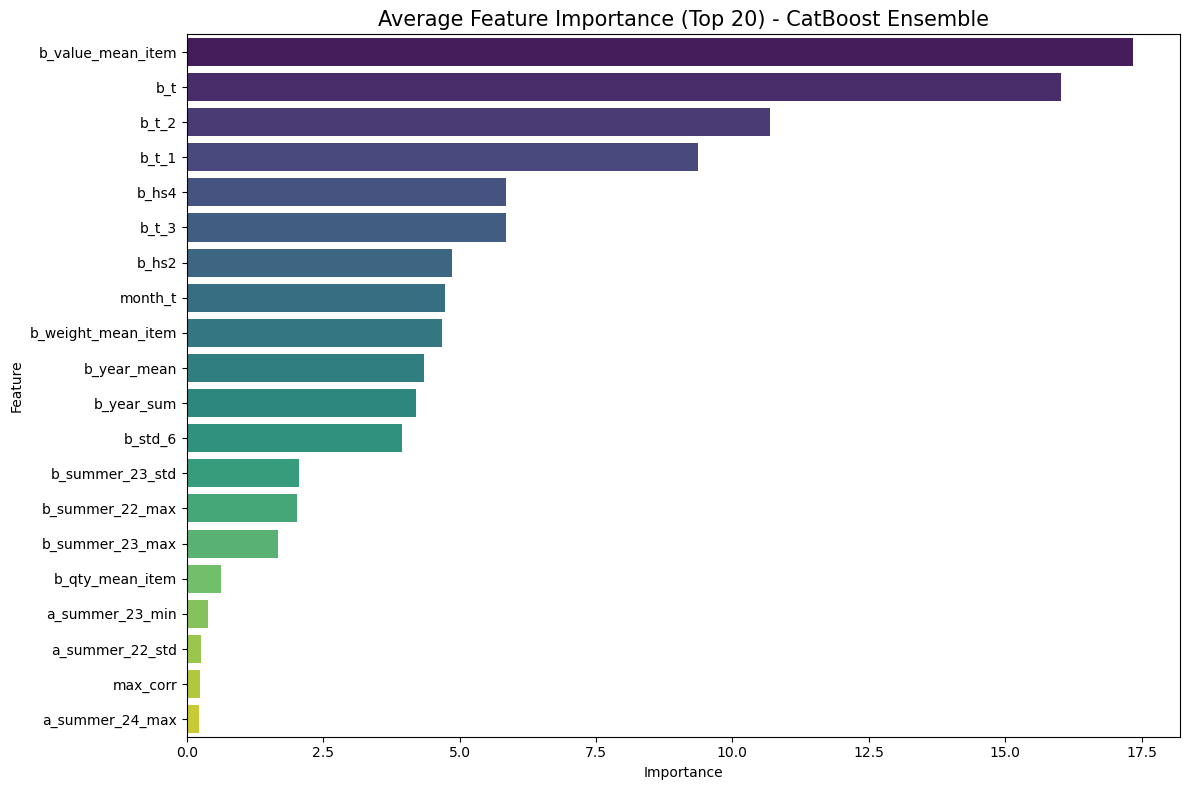


🧹 [Feature Selection] 중요도 0인 피처 확인
💀 중요도 0인 피처 개수: 0개
🎉 축하합니다! 모든 피처가 모델 학습에 기여하고 있습니다.


In [31]:
# ==========================================
# 5) 피처 중요도 시각화 & 무의미한 피처 확인
# ==========================================
print("\n📊 피처 중요도 분석 중...")

# 1. 모든 모델의 중요도 평균 계산
all_importances = [m.get_feature_importance() for m in trained_models]
avg_importance = np.mean(all_importances, axis=0)

# 2. 전체 피처 중요도 데이터프레임 생성
full_df_imp = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': avg_importance
})

# 3. 상위 20개 피처 시각화
top20_df = full_df_imp.sort_values(by='Importance', ascending=False).head(20)

plt.figure(figsize=(12, 8))
sns.barplot(data=top20_df, x='Importance', y='Feature', palette='viridis')
plt.title('Average Feature Importance (Top 20) - CatBoost Ensemble', fontsize=15)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 🔥 [추가됨] 중요도가 0인 피처 목록 출력
# ---------------------------------------------------------
print("\n🧹 [Feature Selection] 중요도 0인 피처 확인")

# 중요도가 정확히 0인 것 찾기
zero_imp_features = full_df_imp[full_df_imp['Importance'] == 0]['Feature'].tolist()

print(f"💀 중요도 0인 피처 개수: {len(zero_imp_features)}개")

if len(zero_imp_features) > 0:
    print("🗑️ 제거 대상 피처 목록 (복사해서 feature_cols에서 제외하세요):")
    print(zero_imp_features)
    
    # (선택사항) 0에 가까운 하위 피처들도 확인하고 싶다면 아래 주석 해제
    # low_imp_features = full_df_imp[full_df_imp['Importance'] < 1e-4]['Feature'].tolist()
    # print(f"\n⚠️ 중요도가 매우 낮은(< 0.0001) 피처 개수: {len(low_imp_features)}개")
    # print(low_imp_features)
else:
    print("🎉 축하합니다! 모든 피처가 모델 학습에 기여하고 있습니다.")

## 5. 회귀 모델 추론 및 제출(submission) 파일 생성
- 탐색된 공행성 쌍에 대해 후행 품목(following_item_id)에 대한 2025년 8월 총 무역량(value) 예측

In [32]:
def predict(pivot, pairs, reg, train):
    months = pivot.columns.to_list()
    n_months = len(months)
    years = np.array([dt.year for dt in months])
    months_num = np.array([dt.month for dt in months])

    # ---------------------------------------------------------
    # 🧱 0. train 기반 품목 메타 정보(정적인 피처) 계산
    # ---------------------------------------------------------
    item_meta = (
        train
        .groupby("item_id", as_index=False)
        .agg(
            hs4=("hs4", "first"),
            weight_mean=("weight", "mean"),
            weight_sum=("weight", "sum"),
            qty_mean=("quantity", "mean"),
            qty_sum=("quantity", "sum"),
            value_mean=("value", "mean")
        )
    )
    item_meta["hs2"] = (item_meta["hs4"] // 100).astype(int)
    item_meta = item_meta.set_index("item_id")

    meta_dict = item_meta.to_dict(orient="index")
    meta_default = {
        "hs4": 0,
        "hs2": 0,
        "weight_mean": 0.0,
        "weight_sum": 0.0,
        "qty_mean": 0.0,
        "qty_sum": 0.0,
        "value_mean": 0.0,
    }

    # ---------------------------------------------------------
    # 📊 연도별 & 여름 통계
    # ---------------------------------------------------------
    print("📊 예측용 연도별/여름 통계 사전 계산 중...")
    
    yearly_stats = {}
    summer_stats_by_year = {}

    unique_years = np.unique(years)
    items_list = pivot.index.to_list()
    pivot_values = pivot.values
    SUMMER_MONTHS = [6, 7, 8]

    for y in unique_years:
        mask_y = (years == y)
        if not np.any(mask_y): continue

        data_y = pivot_values[:, mask_y]

        with np.errstate(divide='ignore', invalid='ignore'):
            m_y = np.nanmean(data_y, axis=1)
            s_y = np.nansum(data_y, axis=1)

        for i, item in enumerate(items_list):
            yearly_stats[(item, y)] = (
                0.0 if np.isnan(m_y[i]) else m_y[i],
                0.0 if np.isnan(s_y[i]) else s_y[i]
            )

        mask_summer = mask_y & np.isin(months_num, SUMMER_MONTHS)
        if np.any(mask_summer):
            data_s = pivot_values[:, mask_summer]
            with np.errstate(divide='ignore', invalid='ignore'):
                feat_mean = np.nanmean(data_s, axis=1)
                feat_sum  = np.nansum(data_s, axis=1)
                feat_std  = np.nanstd(data_s, axis=1)
                feat_max  = np.nanmax(data_s, axis=1)
                feat_min  = np.nanmin(data_s, axis=1)
                feat_gap  = feat_max - feat_min

            for i, item in enumerate(items_list):
                summer_stats_by_year[(item, y)] = {
                    'mean': 0.0 if np.isnan(feat_mean[i]) else feat_mean[i],
                    'sum':  0.0 if np.isnan(feat_sum[i])  else feat_sum[i],
                    'std':  0.0 if np.isnan(feat_std[i])  else feat_std[i],
                    'max':  0.0 if np.isnan(feat_max[i])  else feat_max[i],
                    'min':  0.0 if np.isnan(feat_min[i])  else feat_min[i],
                    'gap':  0.0 if np.isnan(feat_gap[i])  else feat_gap[i]
                }

    print("✅ 예측 데이터 생성 및 추론 시작")

    rows = []
    ids_for_submission = []

    t = n_months - 1
    year_t = years[t]
    month_t = months_num[t]
    TARGET_SUMMER_YEARS = [2022, 2023, 2024, 2025]

    for row in tqdm(pairs.itertuples(index=False), total=len(pairs)):
        leader = row.leading_item_id
        follower = row.following_item_id
        lag = int(row.best_lag)
        corr = float(row.max_corr)

        if leader not in pivot.index or follower not in pivot.index: continue
        if t < max(lag + 2, 6): continue

        a_series = pivot.loc[leader].values.astype(float)
        b_series = pivot.loc[follower].values.astype(float)

        meta_a = meta_dict.get(leader, meta_default)
        meta_b = meta_dict.get(follower, meta_default)

        a_hs4 = int(meta_a["hs4"])
        b_hs4 = int(meta_b["hs4"])
        a_hs2 = int(meta_a["hs2"])
        b_hs2 = int(meta_b["hs2"])
        same_hs2 = 1 if a_hs2 == b_hs2 and a_hs2 != 0 else 0

        pair_static_feats = {
            "a_hs4": a_hs4, "b_hs4": b_hs4,
            "a_hs2": a_hs2, "b_hs2": b_hs2,
            "same_hs2": same_hs2,
            "a_weight_mean_item": float(meta_a["weight_mean"]),
            "b_weight_mean_item": float(meta_b["weight_mean"]),
            "a_weight_sum_item": float(meta_a["weight_sum"]),
            "b_weight_sum_item": float(meta_b["weight_sum"]),
            "a_qty_mean_item": float(meta_a["qty_mean"]),
            "b_qty_mean_item": float(meta_b["qty_mean"]),
            "a_qty_sum_item": float(meta_a["qty_sum"]),
            "b_qty_sum_item": float(meta_b["qty_sum"]),
            "a_value_mean_item": float(meta_a["value_mean"]),
            "b_value_mean_item": float(meta_b["value_mean"]),
        }

        pair_static_feats["weight_mean_ratio_a_over_b"] = pair_static_feats["a_weight_mean_item"] / (pair_static_feats["b_weight_mean_item"] + 1e-8)
        pair_static_feats["qty_mean_ratio_a_over_b"] = pair_static_feats["a_qty_mean_item"] / (pair_static_feats["b_qty_mean_item"] + 1e-8)
        pair_static_feats["value_mean_ratio_a_over_b"] = pair_static_feats["a_value_mean_item"] / (pair_static_feats["b_value_mean_item"] + 1e-8)

        # Rolling & lag features
        b_roll_mean_3_lag1 = np.mean(b_series[t-3:t]) if t >= 3 else 0.0
        b_std_6 = np.std(b_series[t-5:t+1]) if t >= 5 else 0.0
        idx_a = t - lag
        a_roll_mean_3_lag = np.mean(a_series[idx_a-2:idx_a+1]) if idx_a >= 2 else 0.0

        b_t = b_series[t]
        b_t_1 = b_series[t-1]
        b_t_2 = b_series[t-2]
        b_t_3 = b_series[t-3]

        a_t_lag = a_series[t-lag]
        a_t_lag_1 = a_series[t-lag-1]

        b_diff = b_t - b_t_1
        a_diff_lag = a_t_lag - a_t_lag_1
        ratio_a_b = a_t_lag / (b_t + 1e-8)
        ratio_diff = a_diff_lag / (b_diff + 1e-8) if abs(b_diff) > 1e-9 else 0.0

        prev_year = year_t - 1
        b_yr_mean, b_yr_sum = yearly_stats.get((follower, prev_year), (0.0, 0.0))
        a_yr_mean, a_yr_sum = yearly_stats.get((leader, prev_year), (0.0, 0.0))

        row_dict = {
            "b_t": b_t, "b_t_1": b_t_1, "b_t_2": b_t_2, "b_t_3": b_t_3,
            "b_diff": b_diff, "b_roll_mean_3_lag1": b_roll_mean_3_lag1, "b_std_6": b_std_6,
            "a_t_lag": a_t_lag, "a_diff_lag": a_diff_lag, "a_roll_mean_3_lag": a_roll_mean_3_lag,
            "max_corr": corr, "best_lag": float(lag), "ratio_a_b": ratio_a_b, "ratio_diff": ratio_diff,
            "month_t": float(month_t),
            "b_year_mean": b_yr_mean, "b_year_sum": b_yr_sum,
            "a_year_mean": a_yr_mean, "a_year_sum": a_yr_sum,
        }

        row_dict.update(pair_static_feats)

        for target_y in TARGET_SUMMER_YEARS:
            stats_b = summer_stats_by_year.get((follower, target_y), {'mean':0,'sum':0,'std':0,'max':0,'min':0,'gap':0})
            stats_a = summer_stats_by_year.get((leader, target_y), {'mean':0,'sum':0,'std':0,'max':0,'min':0,'gap':0})

            suffix = str(target_y)[-2:]
            for k in ['mean', 'sum', 'std', 'max', 'min', 'gap']:
                row_dict[f"b_summer_{suffix}_{k}"] = stats_b[k]
                row_dict[f"a_summer_{suffix}_{k}"] = stats_a[k]

        rows.append(row_dict)
        ids_for_submission.append({"leading_item_id": leader, "following_item_id": follower})

    X_test_df = pd.DataFrame(rows).fillna(0.0)
    try:
        X_test = X_test_df[feature_cols]
    except:
        X_test = X_test_df

    y_pred = reg.predict(X_test)

    df_pred = pd.DataFrame(ids_for_submission)
    df_pred["value"] = np.maximum(0, y_pred).round().astype(int)

    return df_pred

In [33]:
# ======================================================
# 📁 제출 파일 자동 생성 (날짜+시간+모델명 포함)
# ======================================================
# 현재 시각 문자열 생성
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# 모델명 자동 추출
MODEL = model
model_name = MODEL.__class__.__name__

# 파일명 지정
SUBMISSION_PATH = f"./submission/BEST_BASELINE_p_corr_dtw_v1_{timestamp}.csv"

# SUBMISSION 생성
submission = predict(pivot, pairs, MODEL, train)

# 저장
submission.to_csv(SUBMISSION_PATH, index=False)

print(f"✅ 제출 파일 저장 완료: {SUBMISSION_PATH}")

📊 예측용 연도별/여름 통계 사전 계산 중...
✅ 예측 데이터 생성 및 추론 시작


100%|██████████| 1549/1549 [00:00<00:00, 21766.00it/s]

✅ 제출 파일 저장 완료: ./submission/BEST_BASELINE_p_corr_dtw_v1_20251127_230223.csv


# ==============================================